# Balkan Film Production Analysis

Graphs exploring the number of films produced over time — overall and by country.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


df = pd.read_csv('data/balkan_movies_confirmed.csv')


df = df.dropna(subset=['year_final'])
df['year'] = df['year_final'].astype(int)


df = df[(df['year'] >= 1945) & (df['year'] <= 2024)]


def primary_country(val):
    if pd.isna(val):
        return None
    for sep in ['|', ',']:
        if sep in val:
            return val.split(sep)[0].strip()
    return val.strip()

df['primary_country'] = df['country'].apply(primary_country)

BALKAN_COUNTRIES = [
    'Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia',
    'Greece', 'Kosovo', 'Montenegro', 'North Macedonia', 'Romania',
    'Serbia', 'Slovenia', 'Yugoslavia'
]

NAME_MAP = {
    "People's Republic of Bulgaria": "Bulgaria",
    "Macedonia": "North Macedonia",
    "Serbia and Montenegro": "Serbia",
}
df['primary_country'] = df['primary_country'].replace(NAME_MAP)

df_balkan = df[df['primary_country'].isin(BALKAN_COUNTRIES)].copy()

print(f"Total films (filtered): {len(df_balkan)}")
print(df_balkan['primary_country'].value_counts())

Total films (filtered): 12645
primary_country
Greece                    2890
Yugoslavia                2295
Romania                   2278
Bulgaria                  1421
Serbia                    1004
Croatia                    852
Slovenia                   577
Albania                    446
Bosnia and Herzegovina     368
North Macedonia            364
Kosovo                      77
Montenegro                  73
Name: count, dtype: int64


## 1. Total Films Produced Each Year (All Countries Combined)

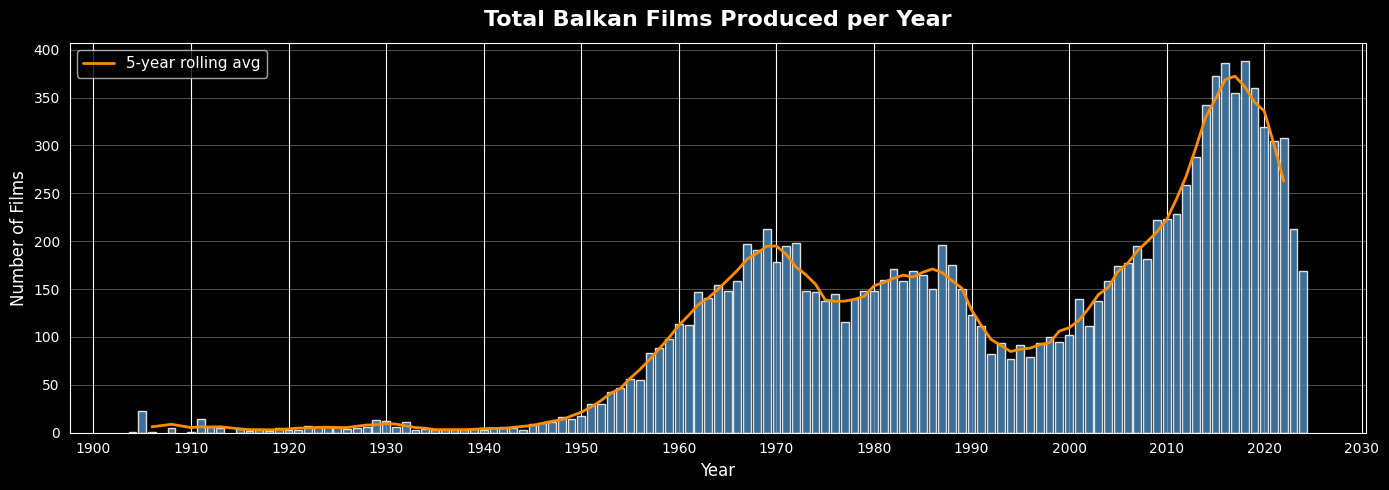

In [2]:
films_per_year = df_balkan.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(films_per_year['year'], films_per_year['count'], color='steelblue', width=0.8, alpha=0.85)

rolling = films_per_year.set_index('year')['count'].rolling(5, center=True).mean()
ax.plot(rolling.index, rolling.values, color='darkorange', linewidth=2, label='5-year rolling avg')

ax.set_title('Total Balkan Films Produced per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films', fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('total_films_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Films per Year — Individual Country Graphs

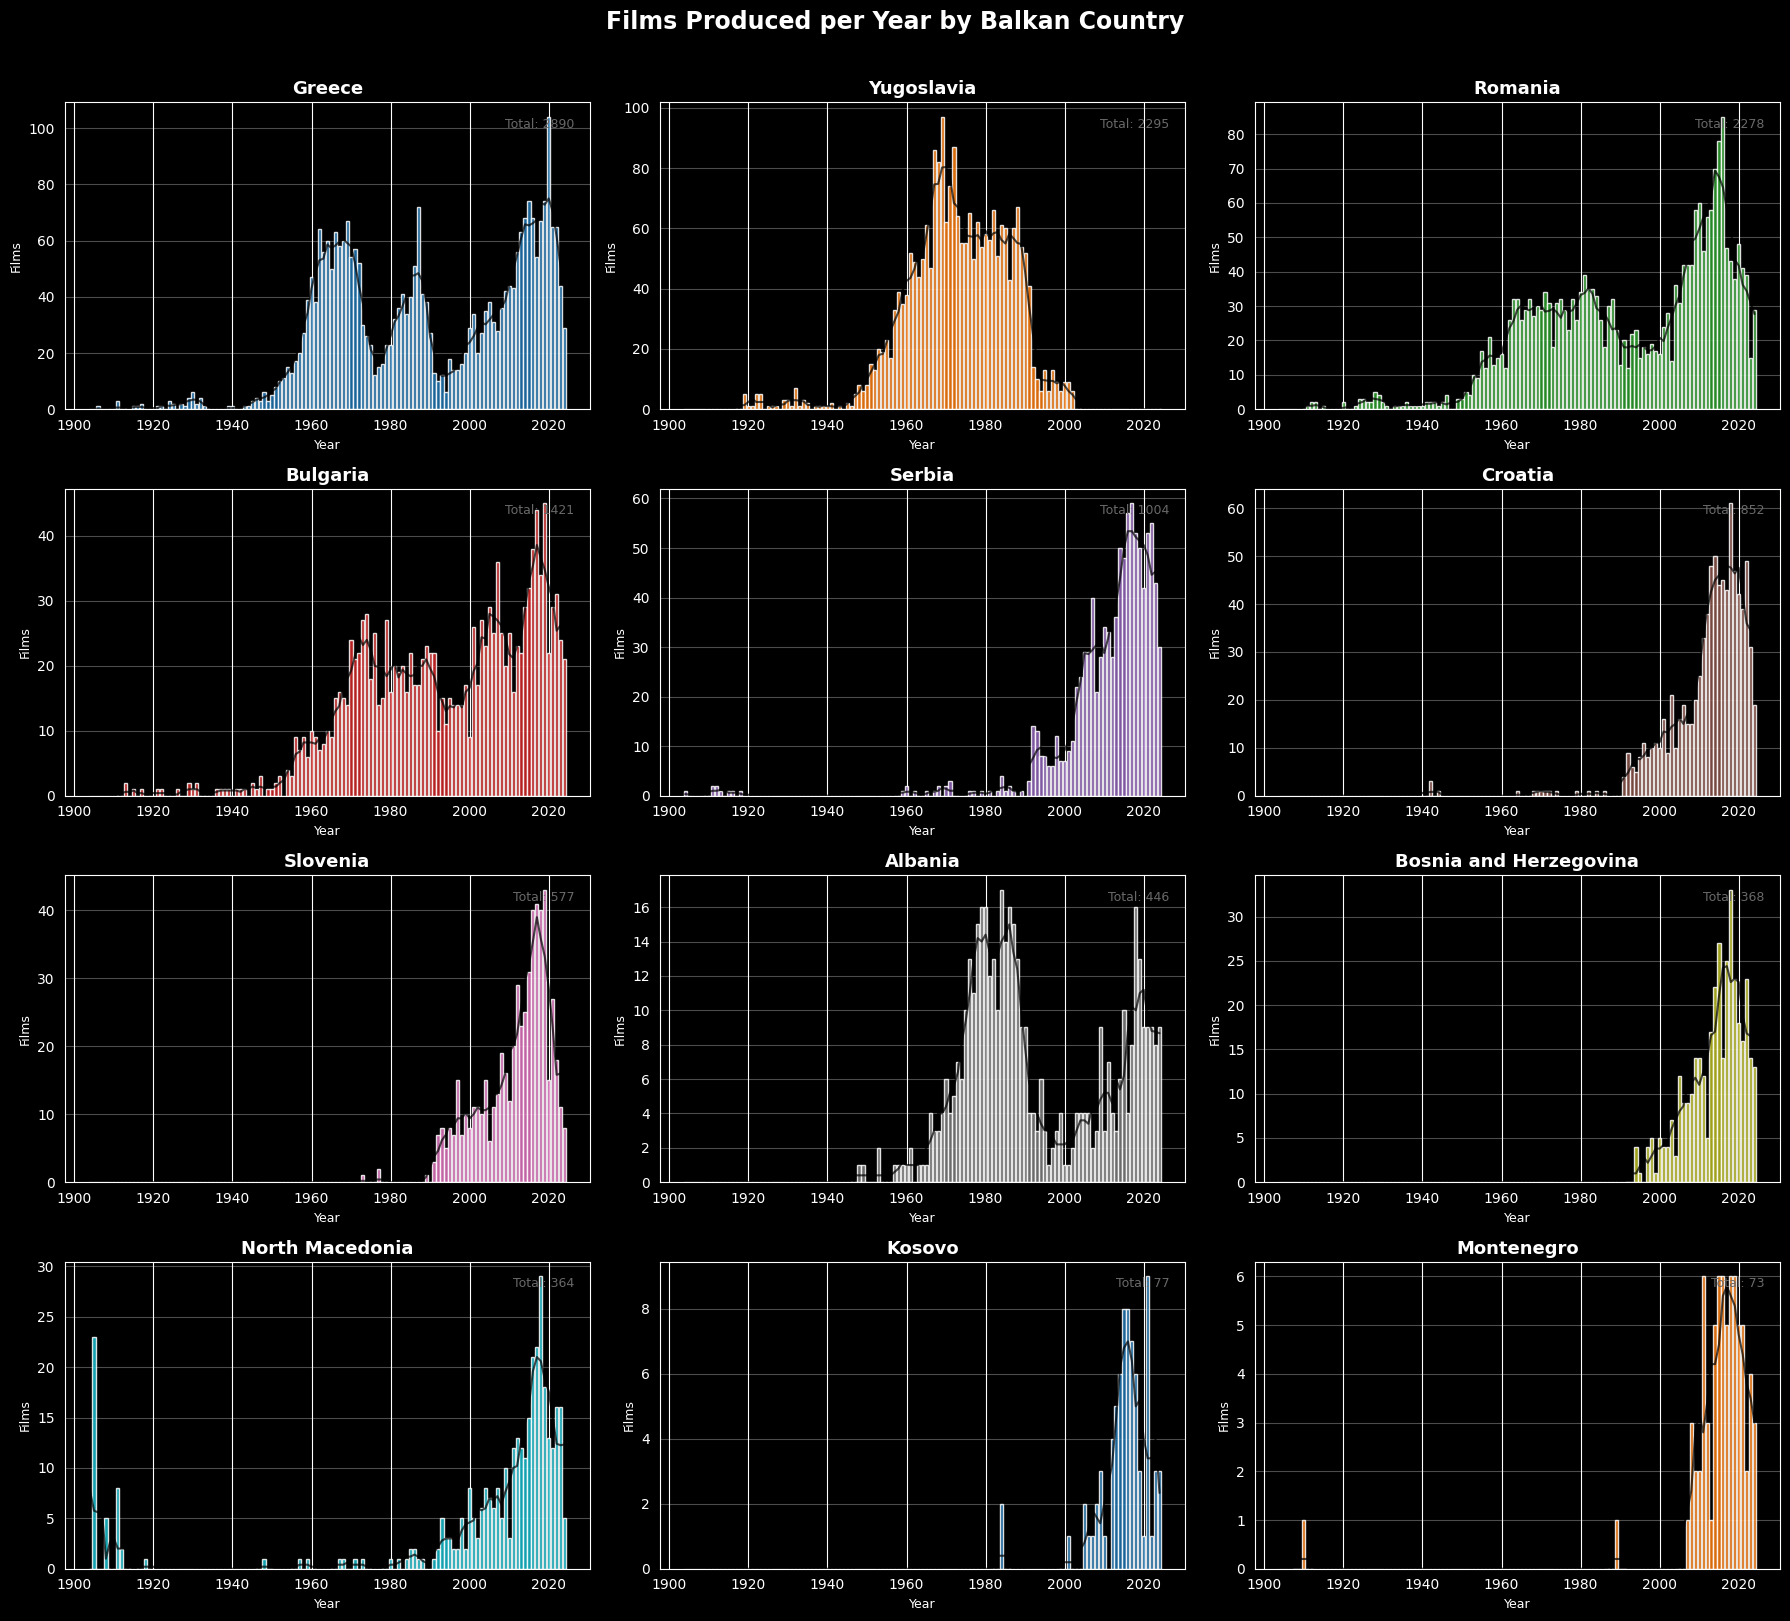

In [6]:
country_order = (
    df_balkan['primary_country']
    .value_counts()
    .index.tolist()
)

palette = sns.color_palette('tab10', n_colors=len(country_order))
color_map = dict(zip(country_order, palette))

all_years = range(df_balkan['year'].min(), df_balkan['year'].max() + 1)

n_cols = 3
n_rows = -(-len(country_order) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, country in enumerate(country_order):
    ax = axes[i]
    subset = df_balkan[df_balkan['primary_country'] == country]
    counts = subset.groupby('year').size().reindex(all_years, fill_value=0)

    ax.bar(counts.index, counts.values, color=color_map[country], width=0.8, alpha=0.85)

    if counts.sum() >= 10:
        roll = counts.rolling(5, center=True, min_periods=2).mean()
        ax.plot(roll.index, roll.values, color='black', linewidth=1.5, alpha=0.7)

    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Films', fontsize=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.grid(axis='y', alpha=0.3)
    total = counts.sum()
    ax.annotate(f'Total: {total}', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='dimgray')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Films Produced per Year by Balkan Country', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('films_per_year_by_country_individual.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. All Countries Together — Films per Year (Multi-line)

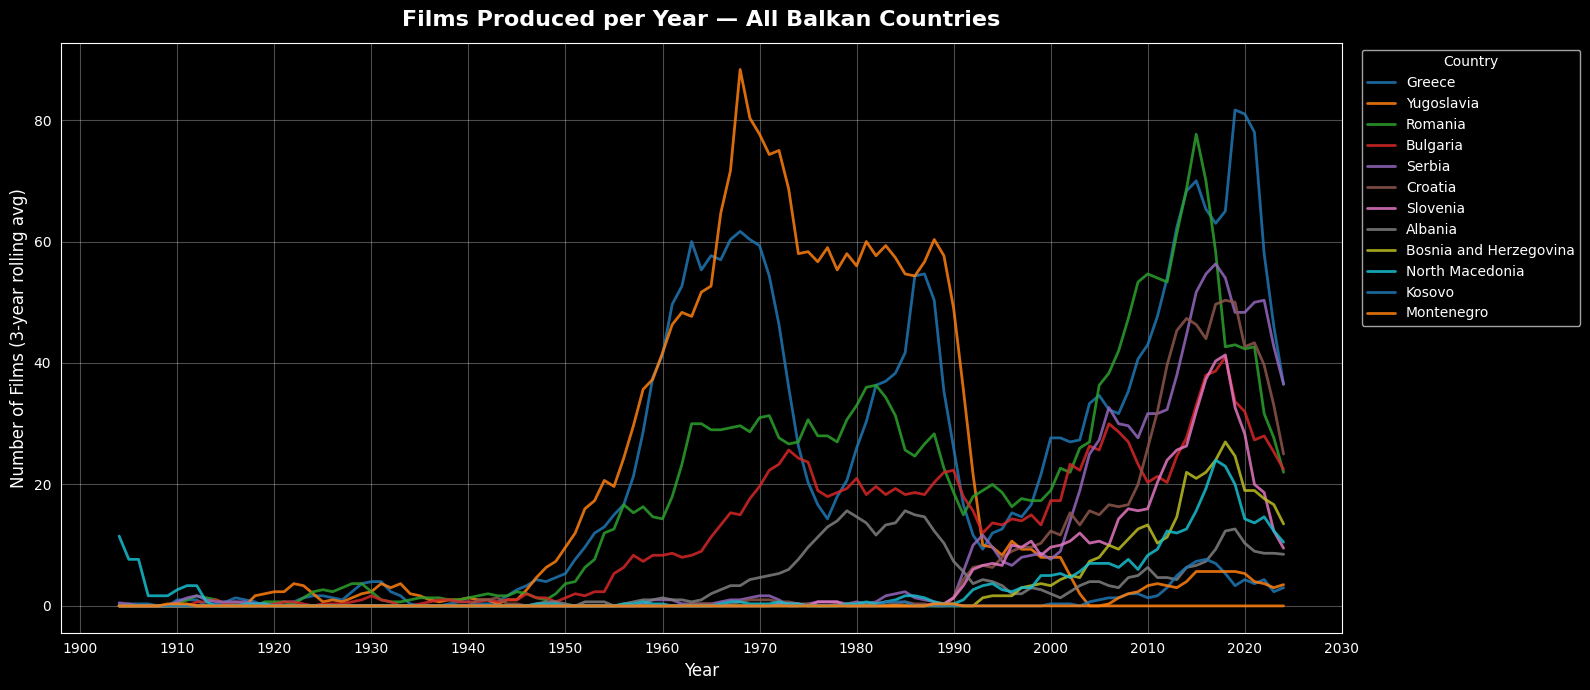

In [4]:
pivot = (
    df_balkan
    .groupby(['year', 'primary_country'])
    .size()
    .unstack(fill_value=0)
    .reindex(all_years, fill_value=0)
)

pivot = pivot[country_order]

fig, ax = plt.subplots(figsize=(16, 7))

for country in country_order:
    series = pivot[country].rolling(3, center=True, min_periods=1).mean()
    ax.plot(pivot.index, series, label=country,
            color=color_map[country], linewidth=2, alpha=0.85)

ax.set_title('Films Produced per Year — All Balkan Countries', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films (3-year rolling avg)', fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(alpha=0.3)
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('films_per_year_all_countries.png', dpi=150, bbox_inches='tight')
plt.show()

## Bonus: Stacked Area Chart — Share of Production by Country

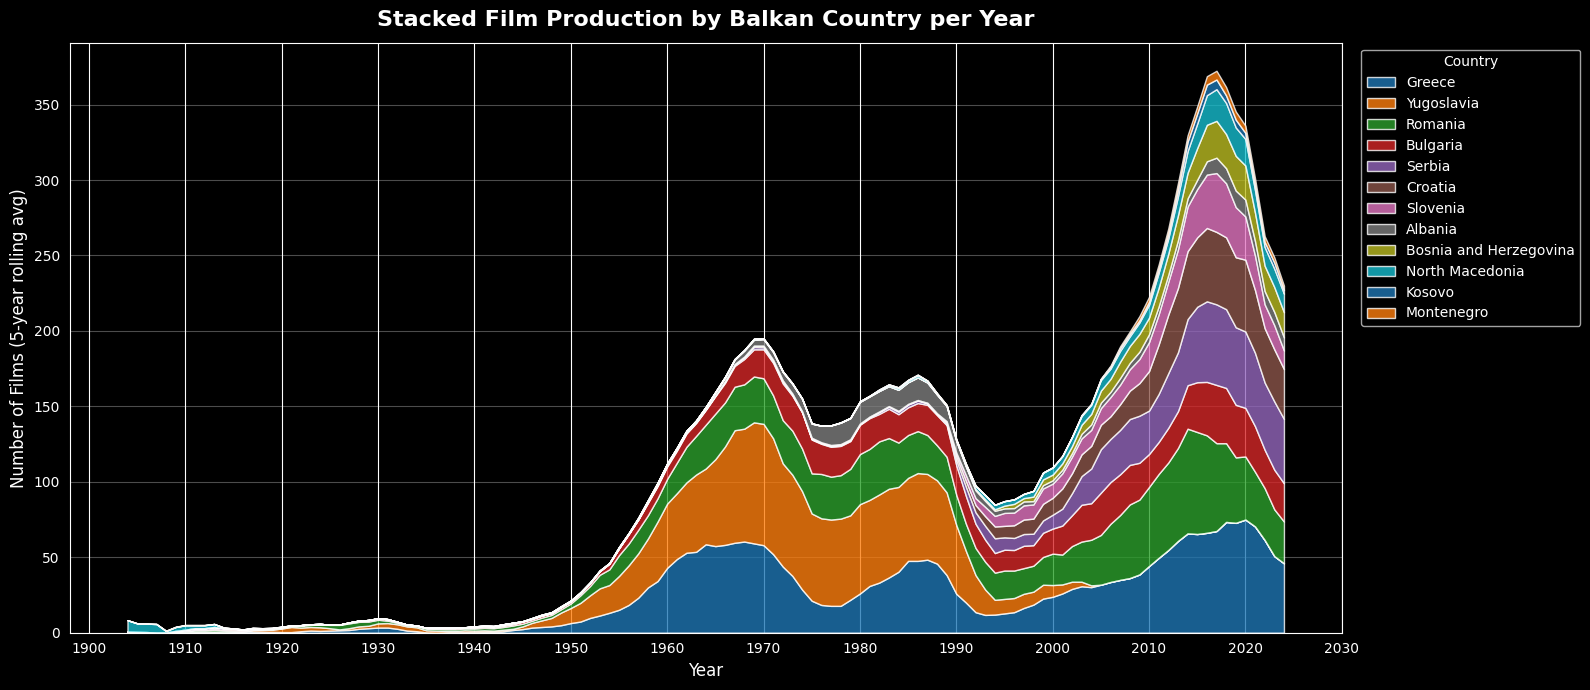

In [5]:
fig, ax = plt.subplots(figsize=(16, 7))

smoothed = pivot.rolling(5, center=True, min_periods=1).mean()

ax.stackplot(
    smoothed.index,
    [smoothed[c] for c in country_order],
    labels=country_order,
    colors=[color_map[c] for c in country_order],
    alpha=0.8
)

ax.set_title('Stacked Film Production by Balkan Country per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films (5-year rolling avg)', fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('films_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()